# Low-Light Image Enhancement Pipeline
## MIRNet (Enhancement) → DAT-x4 (Super-Resolution / Sharpening)

**Pipeline:**
```
Input (dark image) --> MIRNet (brighten & denoise) --> DAT-x4 (4x super-resolution) --> Output
```

| Stage | Model | Effect |
|-------|-------|--------|
| Stage 1 | **MIRNet** (Multi-Scale Residual Network) | Low-light enhancement, brightness recovery |
| Stage 2 | **DAT-x4** (Dual Aggregation Transformer) | 4x super-resolution, sharpening, detail recovery |

---
## 1. Setup & Dependencies

In [ ]:
!pip install timm einops -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, sys, time, math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import OrderedDict
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
print(f"  PyTorch: {torch.__version__}")

Device: cuda
  GPU: Tesla T4
  PyTorch: 2.11.0+cu128


---
## 2. Configuration

In [ ]:
# ── Paths (Update for your environment) ──
# For Colab:
BASE_DIR = r"/content/drive/MyDrive/Final year project/final year project"
# BASE_DIR = r"."

MIRNET_CHECKPOINT = os.path.join(BASE_DIR, "checkpoints_mirnet", "mirnet_best.pth")
TEST_DIR          = os.path.join(BASE_DIR, "test", "low")
OUTPUT_DIR        = os.path.join(BASE_DIR, "test", "pipeline_mirnet_cv_output")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Paths configured:")
print(f"  MIRNet checkpoint: {MIRNET_CHECKPOINT}  (exists: {os.path.exists(MIRNET_CHECKPOINT)})")
print(f"  DAT-x4 checkpoint: {DAT_CHECKPOINT}  (exists: {os.path.exists(DAT_CHECKPOINT)})")
print(f"  Test images:       {TEST_DIR}")
print(f"  Output:            {OUTPUT_DIR}")

Paths configured:
  MIRNet checkpoint: /content/drive/MyDrive/Final year project/final year project/checkpoints_mirnet/mirnet_best.pth  (exists: True)
  DAT-x4 checkpoint: /content/drive/MyDrive/Final year project/final year project/sharpness_model/DAT_x4.pth  (exists: True)
  Test images:       /content/drive/MyDrive/Final year project/final year project/test/low
  Output:            /content/drive/MyDrive/Final year project/final year project/test/pipeline_mirnet_cv_output


---
## 3. MIRNet Architecture

In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, num_features, reduction=4):
        super().__init__()
        self.module = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(num_features, num_features // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(num_features // reduction, num_features, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.module(x).unsqueeze(-1).unsqueeze(-1)

class SpatialAttention(nn.Module):
    def __init__(self, num_features, reduction=4):
        super().__init__()
        self.module = nn.Sequential(
            nn.Conv2d(num_features, num_features // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features // reduction, 1, 1, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.module(x)

class DAU(nn.Module):
    def __init__(self, num_features, reduction=4):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_features, num_features, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features, num_features, 3, padding=1, bias=False),
        )
        self.ca = ChannelAttention(num_features, reduction)
        self.sa = SpatialAttention(num_features, reduction)
        self.conv_tail = nn.Conv2d(num_features * 2, num_features, 1, bias=False)
    def forward(self, x):
        res = self.body(x)
        return self.conv_tail(torch.cat([self.ca(res), self.sa(res)], dim=1)) + x

class SKFF(nn.Module):
    def __init__(self, num_features, num_paths=2, reduction=4):
        super().__init__()
        d = max(num_features // reduction, 4)
        self.fc_squeeze = nn.Linear(num_features, d, bias=False)
        self.fcs = nn.ModuleList([nn.Linear(d, num_features, bias=False) for _ in range(num_paths)])
        self.softmax = nn.Softmax(dim=1)
    def forward(self, feats):
        B, C, H, W = feats[0].shape
        gap = F.adaptive_avg_pool2d(sum(feats), 1).view(B, C)
        z = F.relu(self.fc_squeeze(gap))
        attn = self.softmax(torch.stack([fc(z) for fc in self.fcs], dim=1))
        out = torch.zeros_like(feats[0])
        for i, feat in enumerate(feats):
            out = out + feat * attn[:, i, :].unsqueeze(-1).unsqueeze(-1)
        return out

class DownSample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.down = nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1, bias=False), nn.ReLU(inplace=True))
    def forward(self, x):
        return self.down(x)

class UpSample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Sequential(nn.Conv2d(in_ch, out_ch * 4, 1, bias=False), nn.PixelShuffle(2), nn.ReLU(inplace=True))
    def forward(self, x):
        return self.up(x)

class MRB(nn.Module):
    def __init__(self, n_feat, reduction=4):
        super().__init__()
        self.dau_s1 = DAU(n_feat, reduction)
        self.dau_s2 = DAU(n_feat, reduction)
        self.down_12 = DownSample(n_feat, n_feat)
        self.up_21 = UpSample(n_feat, n_feat)
        self.conv_s1 = nn.Conv2d(n_feat * 2, n_feat, 1, bias=False)
        self.conv_s2 = nn.Conv2d(n_feat * 2, n_feat, 1, bias=False)
        self.skff = SKFF(n_feat, 2, reduction)
    def forward(self, x):
        x_s2 = self.down_12(x)
        o1, o2 = self.dau_s1(x), self.dau_s2(x_s2)
        s2_up = F.interpolate(self.up_21(o2), size=o1.shape[2:], mode='bilinear', align_corners=False)
        s1_f = self.conv_s1(torch.cat([o1, s2_up], 1))
        s1_dn = F.interpolate(self.down_12(o1), size=o2.shape[2:], mode='bilinear', align_corners=False)
        s2_f = self.conv_s2(torch.cat([o2, s1_dn], 1))
        s2_up2 = F.interpolate(s2_f, size=s1_f.shape[2:], mode='bilinear', align_corners=False)
        return self.skff([s1_f, s2_up2]) + x

class RRG(nn.Module):
    def __init__(self, n_feat, n_mrb, reduction=4):
        super().__init__()
        modules = [MRB(n_feat, reduction) for _ in range(n_mrb)]
        modules.append(nn.Conv2d(n_feat, n_feat, 3, padding=1, bias=False))
        self.body = nn.Sequential(*modules)
    def forward(self, x):
        return self.body(x) + x

class MIRNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, n_features=64, n_rrg=3, n_mrb=2, reduction=4):
        super().__init__()
        self.shallow_feat = nn.Conv2d(in_channels, n_features, 3, padding=1, bias=False)
        self.rrgs = nn.Sequential(*[RRG(n_features, n_mrb, reduction) for _ in range(n_rrg)])
        self.reconstruct = nn.Conv2d(n_features, out_channels, 3, padding=1, bias=False)
    def forward(self, x):
        return (self.reconstruct(self.rrgs(self.shallow_feat(x))) + x).clamp(0, 1)

print("✅ MIRNet architecture defined.")

✅ MIRNet architecture defined.


---
## 5. Load Models

In [ ]:
# ═══════════════════════════════════════════════════════
#  Load MIRNet
# ═══════════════════════════════════════════════════════
mirnet_model = MIRNet(
    in_channels=3, out_channels=3,
    n_features=64, n_rrg=3, n_mrb=2, reduction=4
).to(device)

if os.path.exists(MIRNET_CHECKPOINT):
    ckpt = torch.load(MIRNET_CHECKPOINT, map_location=device, weights_only=False)
    mirnet_model.load_state_dict(ckpt['model_state_dict'])
    epoch = ckpt.get('epoch', '?')
    psnr = ckpt.get('best_psnr', '?')
    psnr_str = f"{psnr:.2f} dB" if isinstance(psnr, (int, float)) else str(psnr)
    print(f"✅ MIRNet loaded (epoch {epoch}, PSNR: {psnr_str})")
else:
    print(f"⚠️  WARNING: MIRNet checkpoint not found at {MIRNET_CHECKPOINT}")

mirnet_model.eval()
print(f"  Parameters: {sum(p.numel() for p in mirnet_model.parameters()):,}")

✅ MIRNet loaded (epoch 130, PSNR: 21.68 dB)
  Parameters: 1,570,368


---
## 6. Pipeline Functions

In [ ]:
def mirnet_enhance(img_tensor, model, device):
    """Low-light enhancement. Input/Output: [3, H, W] in [0, 1]"""
    model.eval()
    with torch.no_grad():
        _, H, W = img_tensor.shape
        pad_h = (8 - H % 8) % 8
        pad_w = (8 - W % 8) % 8
        x = img_tensor.unsqueeze(0).to(device)
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h), mode='reflect')
        out = model(x)
        if pad_h > 0 or pad_w > 0:
            out = out[:, :, :H, :W]
        return out.squeeze(0).clamp(0, 1).cpu()

def full_pipeline(image_path, mirnet, device, save_dir=None):
    """Full pipeline: Image -> MIRNet (enhance) -> DAT (4x SR) -> Output"""
    img = Image.open(image_path).convert('RGB')
    img_tensor = TF.to_tensor(img)
    img_name = os.path.basename(image_path)
    name, ext = os.path.splitext(img_name)

    print(f"  Input: {img_name} ({img.size[0]}x{img.size[1]})")

    # Step 1: MIRNet — Low-light enhancement
    t1 = time.time()
    mirnet_out = mirnet_enhance(img_tensor, mirnet, device)
    t_mirnet = (time.time() - t1) * 1000
    _, mH, mW = mirnet_out.shape
    print(f"  Step 1 (MIRNet Enhance):  {t_mirnet:.0f}ms -> {mW}x{mH}")

    # Step 2: CV
    t2 = time.time()

    # mirnet_output should be an RGB uint8 image (0-255)
    mirnet_output = mirnet_out.squeeze().permute(1,2,0).cpu().numpy()
    mirnet_output = (mirnet_output * 255).clip(0,255).astype(np.uint8)

    mirnet_bgr = cv2.cvtColor(mirnet_output, cv2.COLOR_RGB2BGR)

    # Denoise
    denoised = cv2.fastNlMeansDenoisingColored(
        mirnet_bgr,
        None,
        h=5,
        hColor=5,
        templateWindowSize=7,
        searchWindowSize=21
    )

    # Convert back to RGB
    final_out = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)

    t_dat = (time.time() - t2) * 1000
    _, fH, fW = final_out.shape


    # Save outputs
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        TF.to_pil_image(mirnet_out).save(os.path.join(save_dir, f"{name}_mirnet{ext}"))
        TF.to_pil_image(final_out).save(os.path.join(save_dir, f"{name}_final_cv{ext}"))
        print(f"  Saved to {save_dir}/")

    return img_tensor, mirnet_out, final_out

print("✅ Pipeline functions ready!")

✅ Pipeline functions ready!


---
## 7. Run Pipeline on Test Images

In [ ]:
test_images = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))
])

print(f"Found {len(test_images)} test image(s)")

print("=" * 60)

results = {}
for img_name in test_images:
    img_path = os.path.join(TEST_DIR, img_name)
    print(f"\nProcessing: {img_name}")
    print("-" * 40)
    original, mirnet_out, final_out = full_pipeline(
        img_path, mirnet_model, device,
        save_dir=OUTPUT_DIR,
    )
    results[img_name] = (original, mirnet_out, final_out)

print(f"\n{'=' * 60}")
print(f"Done! Results saved to: {OUTPUT_DIR}")

Found 5 test image(s)

Processing: First.jpeg
----------------------------------------
  Input: First.jpeg (714x284)
  Step 1 (MIRNet Enhance):  200ms -> 714x284
  Saved to /content/drive/MyDrive/Final year project/final year project/test/pipeline_mirnet_cv_output/

Processing: night.jpg
----------------------------------------
  Input: night.jpg (600x334)
  Step 1 (MIRNet Enhance):  167ms -> 600x334
  Saved to /content/drive/MyDrive/Final year project/final year project/test/pipeline_mirnet_cv_output/

Processing: second.jpeg
----------------------------------------
  Input: second.jpeg (572x321)
  Step 1 (MIRNet Enhance):  190ms -> 572x321
  Saved to /content/drive/MyDrive/Final year project/final year project/test/pipeline_mirnet_cv_output/

Processing: test1.png
----------------------------------------
  Input: test1.png (366x246)
  Step 1 (MIRNet Enhance):  100ms -> 366x246
  Saved to /content/drive/MyDrive/Final year project/final year project/test/pipeline_mirnet_cv_output/

Pro

---
## 8. Visual Comparison — 3 Stage View

In [ ]:
for img_name, (original, mirnet_out, final_out) in results.items():
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # Input
    axes[0].imshow(original.permute(1, 2, 0).numpy())
    _, oH, oW = original.shape
    axes[0].set_title(f'Input (Low-Light)\n{oW}x{oH}', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # MIRNet
    axes[1].imshow(mirnet_out.permute(1, 2, 0).numpy())
    _, mH, mW = mirnet_out.shape
    axes[1].set_title(f'Step 1: MIRNet Enhanced\n{mW}x{mH}', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    # OpenCV Denoising
    axes[2].imshow(final_out)
    _, dH, dW = final_out.shape
    axes[2].set_title(
        f'Step 2: FastNlMeans Denoising\n{dW}x{dH}',
        fontsize=14,
        fontweight='bold'
    )
    axes[2].axis('off')

    plt.suptitle(
        f'Pipeline: {img_name}  [MIRNet → FastNlMeansDenoisingColored]',
        fontsize=18,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    # Brightness statistics
    ob = (0.299*original[0] + 0.587*original[1] + 0.114*original[2]).mean().item()
    mb = (0.299*mirnet_out[0] + 0.587*mirnet_out[1] + 0.114*mirnet_out[2]).mean().item()
    db = (0.299*final_out[0] + 0.587*final_out[1] + 0.114*final_out[2]).mean().item()

    print(
        f"{img_name}: brightness {ob*100:.1f}% -> {mb*100:.1f}% -> {db*100:.1f}%"
        f" | res: {oW}x{oH} -> {dW}x{dH}"
    )
    print()

Output hidden; open in https://colab.research.google.com to view.

---
## 9. Try Your Own Image

Pipeline on: /content/drive/MyDrive/Final year project/final year project/test/low/test1.png
  Input: test1.png (366x246)
  Step 1 (MIRNet Enhance):  91ms -> 366x246
  Saved to /content/drive/MyDrive/Final year project/final year project/test/pipeline_mirnet_cv_output/


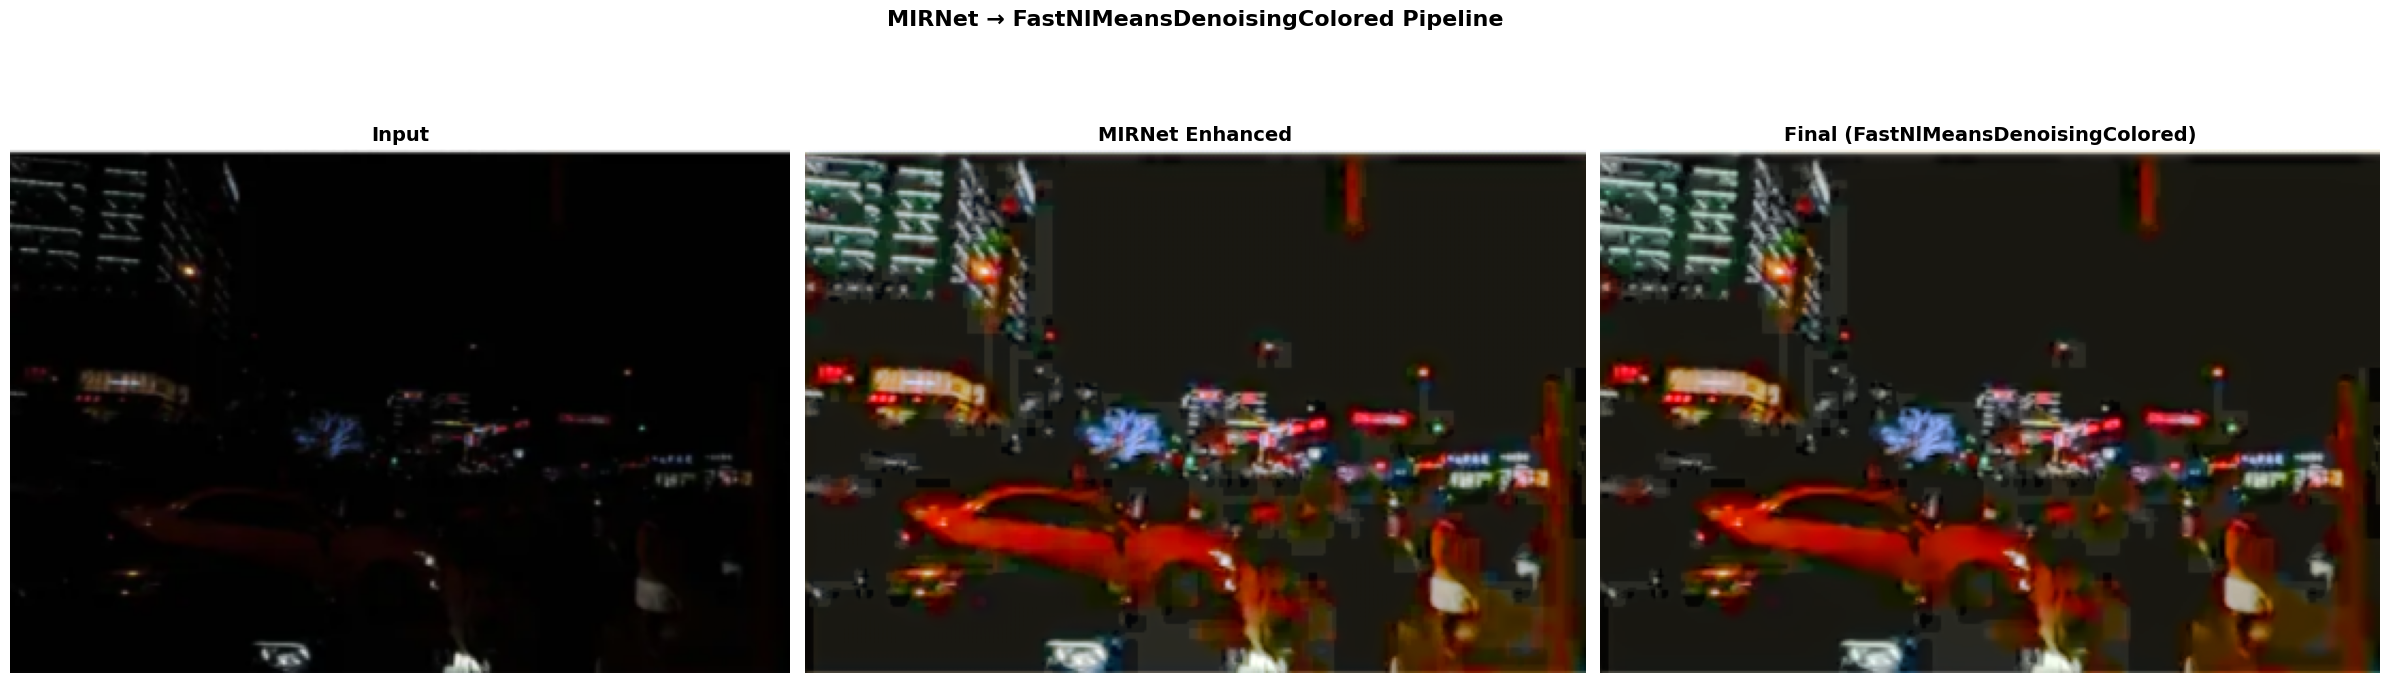

In [ ]:
# ── CHANGE THIS PATH ──
your_image = os.path.join(TEST_DIR, "test1.png")

if os.path.exists(your_image):
    print(f"Pipeline on: {your_image}")
    print("=" * 50)
    original, mirnet_out, final_out = full_pipeline(
        your_image, mirnet_model, device,
        save_dir=OUTPUT_DIR,
    )

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    axes[0].imshow(original.permute(1, 2, 0).numpy())
    axes[0].set_title('Input', fontsize=14, fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(mirnet_out.permute(1, 2, 0).numpy())
    axes[1].set_title('MIRNet Enhanced', fontsize=14, fontweight='bold'); axes[1].axis('off')
    axes[2].imshow(final_out)
    axes[2].set_title(f'Final (FastNlMeansDenoisingColored)', fontsize=14, fontweight='bold'); axes[2].axis('off')
    plt.suptitle('MIRNet → FastNlMeansDenoisingColored Pipeline', fontsize=16, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print(f"Not found: {your_image}")

---
## 10. MIRNet-Only Mode (No FastNlMeansDenoisingColored)

  test1.png (366x246) -> 92ms
  Saved: /content/drive/MyDrive/Final year project/final year project/test/pipeline_mirnet_cv_output/mirnet_only_sample.png


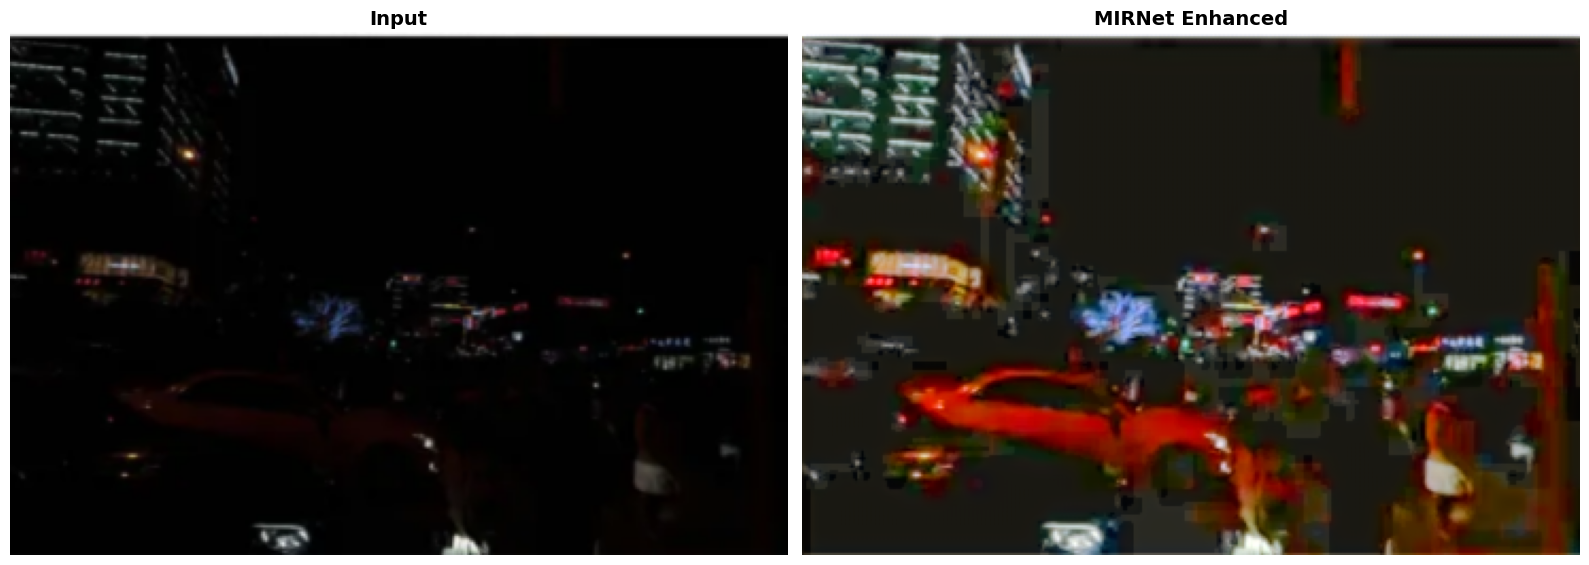

In [ ]:
def mirnet_only(image_path, model, device, save_path=None):
    """Run only MIRNet enhancement (no FastNlMeansDenoisingColored)."""
    img = Image.open(image_path).convert('RGB')
    img_tensor = TF.to_tensor(img)
    start = time.time()
    enhanced = mirnet_enhance(img_tensor, model, device)
    elapsed = (time.time() - start) * 1000
    print(f"  {os.path.basename(image_path)} ({img.size[0]}x{img.size[1]}) -> {elapsed:.0f}ms")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.imshow(img_tensor.permute(1, 2, 0).numpy())
    ax1.set_title('Input', fontsize=14, fontweight='bold'); ax1.axis('off')
    ax2.imshow(enhanced.permute(1, 2, 0).numpy())
    ax2.set_title('MIRNet Enhanced', fontsize=14, fontweight='bold'); ax2.axis('off')
    plt.tight_layout()
    if save_path:
        TF.to_pil_image(enhanced).save(save_path)
        print(f"  Saved: {save_path}")
    plt.show()
    return enhanced

sample = os.path.join(TEST_DIR, os.listdir(TEST_DIR)[0])
_ = mirnet_only(sample, mirnet_model, device,
                save_path=os.path.join(OUTPUT_DIR, "mirnet_only_sample.png"))

---
## 12. Pixel Statistics & Quality Check

In [ ]:
print("Pixel Statistics Analysis — MIRNet → DAT Pipeline")
print("=" * 75)
print(f"{'Image':<20} {'Stage':<16} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
print("-" * 75)

for img_name, (original, mirnet_out, final_out) in results.items():
    o_np = original.permute(1, 2, 0).numpy()
    m_np = mirnet_out.permute(1, 2, 0).numpy()
    f_np = final_out

    print(f"{img_name:<20} {'Input':<16} {o_np.mean():>8.4f} {o_np.std():>8.4f} {o_np.min():>6.3f} {o_np.max():>6.3f}")
    print(f"{'':<20} {'MIRNet':<16} {m_np.mean():>8.4f} {m_np.std():>8.4f} {m_np.min():>6.3f} {m_np.max():>6.3f}")
    print(f"{'':<20} {'DAT-x4 Final':<16} {f_np.mean():>8.4f} {f_np.std():>8.4f} {f_np.min():>6.3f} {f_np.max():>6.3f}")

    boost_mirnet = (m_np.mean() / o_np.mean() - 1) * 100
    boost_total  = (f_np.mean() / o_np.mean() - 1) * 100
    print(f"{'':<20} {'MIRNet Boost':<16} {boost_mirnet:>+7.1f}%")
    print(f"{'':<20} {'Total Boost':<16} {boost_total:>+7.1f}%")
    print("-" * 75)

print("\nPositive boost = brightness successfully increased!")

Pixel Statistics Analysis — MIRNet → DAT Pipeline
Image                Stage                Mean      Std    Min    Max
---------------------------------------------------------------------------
First.jpeg           Input              0.0614   0.0741  0.000  1.000
                     MIRNet             0.3491   0.1924  0.000  1.000
                     DAT-x4 Final      88.1704  48.8131  0.000 254.000
                     MIRNet Boost      +468.3%
                     Total Boost      +143424.5%
---------------------------------------------------------------------------
night.jpg            Input              0.3344   0.2831  0.000  1.000
                     MIRNet             0.6357   0.2856  0.000  1.000
                     DAT-x4 Final     161.5648  72.6694  0.000 254.000
                     MIRNet Boost       +90.1%
                     Total Boost      +48219.0%
---------------------------------------------------------------------------
second.jpeg          Input             